In [1]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
import wandb
from tqdm import tqdm
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
wandb.init(project="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")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: suruchi-kumari (suruchi-kumari-flame-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
# CONFIG 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 16
EPOCHS = 10
IMG_SIZE = 224
NUM_CLASSES = 7
LR = 1e-4

print(DEVICE)

cuda


In [4]:
# Class mapping (exact from your professor doc)
label_map = {'akiec':0, 'bcc':1, 'bkl':2, 'df':3, 'mel':4, 'nv':5, 'vasc':6}
inv_label_map = {v: k for k, v in label_map.items()}
#                             akiec  bcc   bkl   df    mel   nv    vasc
class_weights = torch.tensor([2.0,   2.0,  2.0,  3.0,  4.0,  1.0,  3.0]).to(DEVICE)
# heavy on rare + mel

In [5]:
def dullrazor(image):    
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, thresh = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    mask = cv2.inpaint(image, thresh, 3, cv2.INPAINT_TELEA)
    return mask

In [6]:
#LOAD DATA 
import os
base = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/'

In [7]:
# Safety check so you never get this error again
if not os.path.exists(base + 'HAM10000_metadata.csv'):
    raise FileNotFoundError("Dataset not added! Go to right sidebar → Add Data → search 'skin cancer mnist ham10000' and add it.")
 
df = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

In [8]:
# Fix image paths (two folders - correct version)
def get_image_path(x):
    p1 = base + 'HAM10000_images_part_1/' + x + '.jpg'
    if os.path.exists(p1):
        return p1
    p2 = base + 'HAM10000_images_part_2/' + x + '.jpg'
    if os.path.exists(p2):
        return p2
    raise FileNotFoundError(f"Image {x} not found in either part")
 
df['image_path'] = df['image_id'].apply(get_image_path)
 
df['label'] = df['dx'].map(label_map)

In [9]:
# Stratified split with lesion_id to prevent leakage
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
df['fold'] = -1
for fold, (train_idx, val_idx) in enumerate(gkf.split(df, df['label'], groups=df['lesion_id'])):
    df.loc[val_idx, 'fold'] = fold
 
# proper 3-way split — fold 0 = val, fold 1 = test, folds 2-4 = train
train_df = df[(df.fold != 0) & (df.fold != 1)].reset_index(drop=True)
val_df = df[df.fold == 0].reset_index(drop=True)
test_df = df[df.fold == 1].reset_index(drop=True)
 
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Class distribution reminder:", train_df['dx'].value_counts(normalize=True))

Train: 6009 Val: 2003 Test: 2003
Class distribution reminder: dx
nv       0.675154
bkl      0.106673
mel      0.106673
bcc      0.048594
akiec    0.036612
vasc     0.013813
df       0.012481
Name: proportion, dtype: float64


In [10]:
# DATASET
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
 
    def __len__(self): return len(self.df)
 
    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        img = Image.open(img_path).convert('RGB')
        img = np.array(img)
        img = dullrazor(img)
        label = self.df.iloc[idx]['label']
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
        return img, label

In [11]:
# Augmentation
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.7),
    A.HueSaturationValue(p=0.5),
    A.CoarseDropout(                           
        num_holes_range=(1, 8),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        p=0.5
    ),
    A.ElasticTransform(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [12]:
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [13]:
train_ds = HAMDataset(train_df, train_transform)
val_ds = HAMDataset(val_df, val_transform)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [14]:
# MODEL
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

In [15]:
# LOSS + OPT 
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
 
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (self.alpha[targets] * (1 - pt) ** self.gamma * ce_loss) if self.alpha is not None else ((1 - pt) ** self.gamma * ce_loss)
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss
 
criterion = FocalLoss(alpha=class_weights, gamma=2.0).to(DEVICE)

In [16]:
# criterion = nn.CrossEntropyLoss(weight=class_weights) 
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [17]:
# ECE METRIC
def compute_ece(probs, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    probs_max = np.max(probs, axis=1)
    preds = np.argmax(probs, axis=1)
    for i in range(n_bins):
        mask = (probs_max > bins[i]) & (probs_max <= bins[i + 1])
        if mask.sum() > 0:
            acc  = (preds[mask] == np.array(labels)[mask]).mean()
            conf = probs_max[mask].mean()
            ece += mask.sum() * abs(acc - conf)
    return ece / len(labels)

In [18]:
# TRAIN LOOP 
def train_one_epoch():
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Training Epoch", leave=True)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{running_loss/len(pbar):.4f}"})
        wandb.log({"batch_loss": loss.item()})
    
    avg_loss = running_loss / len(train_loader)
    print(f"→ Epoch average train loss: {avg_loss:.4f}")
    wandb.log({"train_loss": avg_loss})
 
def validate():
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    running_loss = 0.0
    pbar = tqdm(val_loader, desc="Validating", leave=True)
    
    with torch.no_grad():
        for images, labels in pbar:
            images = images.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels.to(DEVICE))
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            
            running_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            
            pbar.set_postfix({'val_loss': f"{running_loss/len(pbar):.4f}"})
    
    avg_val_loss = running_loss / len(val_loader)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    recall_mel = recall_score(all_labels, all_preds, labels=[4], average=None)[0]
    macro_auc = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr', average='macro')
    # =========v3==========
    ece = compute_ece(np.array(all_probs), all_labels)
    # =========v3==========
    
    print(f"→ Val loss: {avg_val_loss:.4f} | Acc: {acc:.4f} | Mel Recall: {recall_mel:.4f} | Macro AUC: {macro_auc:.4f} | ECE: {ece:.4f}")
    print(classification_report(all_labels, all_preds, target_names=label_map.keys()))
    
    # =========v3: added ece + confusion matrix to wandb=========
    wandb.log({"val_loss": avg_val_loss, "val_acc": acc, "mel_recall": recall_mel, "macro_auc": macro_auc,
               "ece": ece,
               "conf_mat": wandb.plot.confusion_matrix(
                   probs=None, y_true=all_labels, preds=all_preds,
                   class_names=list(label_map.keys())
               )})
    return macro_auc, recall_mel
 
best_auc = 0.0
for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{EPOCHS} ===")
    train_one_epoch()
    auc, mel_r = validate()
    scheduler.step()
    
    # =========v3: save on mel recall ≥ 0.95 too, not just best AUC=========
    if auc > best_auc or (mel_r >= 0.95 and auc > 0.90):
        best_auc = auc
        torch.save(model.state_dict(), 'best_b4.pth')
        print(f">>> New best Macro AUC: {best_auc:.4f} — model saved! <<<")
 


=== Epoch 1/10 ===


Training Epoch: 100%|██████████| 376/376 [04:34<00:00,  1.37it/s, loss=4.3568]


→ Epoch average train loss: 4.3568


Validating: 100%|██████████| 126/126 [01:27<00:00,  1.45it/s, val_loss=3.6774]


→ Val loss: 3.6774 | Acc: 0.4863 | Mel Recall: 0.8982 | Macro AUC: 0.7841 | ECE: 0.1367
              precision    recall  f1-score   support

       akiec       0.17      0.07      0.10        56
         bcc       0.43      0.18      0.25       108
         bkl       0.37      0.17      0.23       239
          df       0.00      0.00      0.00        23
         mel       0.19      0.90      0.31       226
          nv       0.96      0.53      0.68      1319
        vasc       0.24      0.19      0.21        32

    accuracy                           0.49      2003
   macro avg       0.34      0.29      0.26      2003
weighted avg       0.73      0.49      0.53      2003

>>> New best Macro AUC: 0.7841 — model saved! <<<

=== Epoch 2/10 ===


...

→ Val loss: 2.4054 | Acc: 0.6720 | Mel Recall: 0.8053 | Macro AUC: 0.9237 | ECE: 0.0350
              precision    recall  f1-score   support

       akiec       0.45      0.54      0.49        56
         bcc       0.57      0.43      0.49       108
         bkl       0.57      0.49      0.52       239
          df       0.43      0.52      0.47        23
         mel       0.30      0.81      0.44       226
          nv       0.95      0.71      0.81      1319
        vasc       0.72      0.72      0.72        32

    accuracy                           0.67      2003
   macro avg       0.57      0.60      0.56      2003
weighted avg       0.79      0.67      0.70      2003

>>> New best Macro AUC: 0.9237 — model saved! <<<

=== Epoch 10/10 ===


Training Epoch: 100%|██████████| 376/376 [04:28<00:00,  1.40it/s, loss=1.9490]


→ Epoch average train loss: 1.9490


Validating: 100%|██████████| 126/126 [01:24<00:00,  1.49it/s, val_loss=2.4458]


→ Val loss: 2.4458 | Acc: 0.6670 | Mel Recall: 0.7965 | Macro AUC: 0.9216 | ECE: 0.0356
              precision    recall  f1-score   support

       akiec       0.45      0.50      0.47        56
         bcc       0.55      0.44      0.49       108
         bkl       0.56      0.53      0.55       239
          df       0.46      0.48      0.47        23
         mel       0.30      0.80      0.43       226
          nv       0.96      0.70      0.81      1319
        vasc       0.56      0.72      0.63        32

    accuracy                           0.67      2003
   macro avg       0.55      0.60      0.55      2003
weighted avg       0.79      0.67      0.70      2003



FINAL TEST EVALUATION 


Testing: 100%|██████████| 126/126 [01:24<00:00,  1.50it/s]


Accuracy     : 0.6615
Macro AUC    : 0.9109  (target ≥ 0.93)
Mel Recall   : 0.7398  (target ≥ 0.95)
ECE          : 0.0517         (target ≤ 0.05)

Classification Report:
              precision    recall  f1-score   support

       akiec       0.33      0.39      0.36        51
         bcc       0.66      0.44      0.53       114
         bkl       0.60      0.60      0.60       219
          df       0.19      0.29      0.23        17
         mel       0.30      0.74      0.43       246
          nv       0.94      0.69      0.79      1329
        vasc       0.56      0.89      0.69        27

    accuracy                           0.66      2003
   macro avg       0.51      0.58      0.52      2003
weighted avg       0.78      0.66      0.70      2003



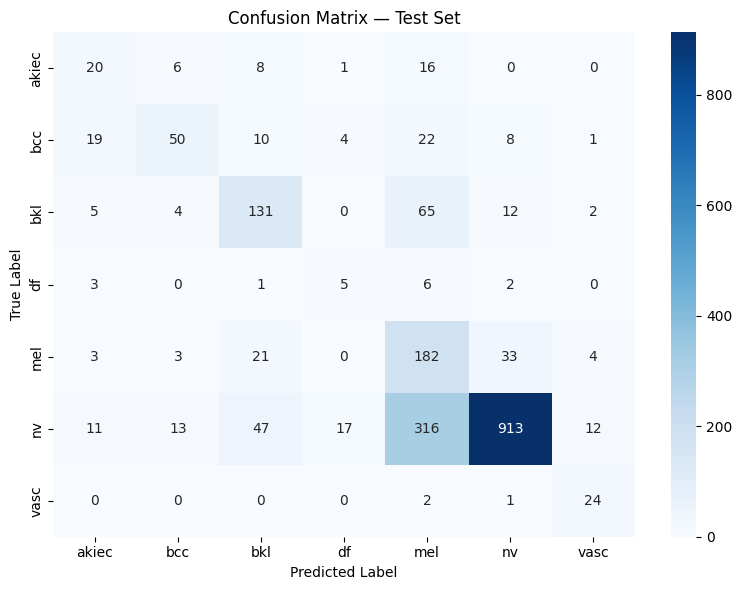

In [19]:
# FINAL TEST EVALUATION 
def evaluate_on_test():
    print("FINAL TEST EVALUATION ")
    model.load_state_dict(torch.load('best_b4.pth'))
    model.eval()
 
    test_ds = HAMDataset(test_df, val_transform)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
 
    all_preds, all_labels, all_probs = [], [], []
 
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing"):
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
 
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
 
    acc        = (np.array(all_preds) == np.array(all_labels)).mean()
    macro_auc  = roc_auc_score(all_labels, np.array(all_probs), multi_class='ovr', average='macro')
    mel_recall = recall_score(all_labels, all_preds, labels=[4], average=None)[0]
    ece        = compute_ece(np.array(all_probs), all_labels)
 
    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro AUC    : {macro_auc:.4f}  (target ≥ 0.93)")
    print(f"Mel Recall   : {mel_recall:.4f}  (target ≥ 0.95)")
    print(f"ECE          : {ece:.4f}         (target ≤ 0.05)")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=label_map.keys()))
 
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=label_map.keys(),
                yticklabels=label_map.keys(),
                cmap='Blues')
    plt.title('Confusion Matrix — Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('confusion_matrix_test.png')
    plt.show()
 
    wandb.log({
        "test_acc": acc, "test_macro_auc": macro_auc,
        "test_mel_recall": mel_recall, "test_ece": ece,
        "test_conf_mat": wandb.Image('confusion_matrix_test.png'),
    })
 
evaluate_on_test()

In [20]:
# CUSTOM SINGLE IMAGE PREDICT 
def predict_single(image_path):
    model.load_state_dict(torch.load('best_b4.pth'))
    model.eval()
 
    img = Image.open(image_path).convert('RGB')
    img = np.array(img)
    img = dullrazor(img)
 
    augmented = val_transform(image=img)
    tensor = augmented['image'].unsqueeze(0).to(DEVICE)
 
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred_idx = probs.argmax()
 
    
    print(f"  Predicted : {inv_label_map[pred_idx].upper()}")
    print(f"  Confidence: {probs[pred_idx]*100:.1f}%")
    
    print("  All class probabilities:")
    for cls, prob in sorted(zip(label_map.keys(), probs), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"    {cls:<6} {prob*100:5.1f}%  {bar}")
 
    return inv_label_map[pred_idx], probs
 


--- Running Model Search Test ---
Model 'EfficientNet_B4' loaded and ready for inference.
--- Starting 10 Random Predictions ---


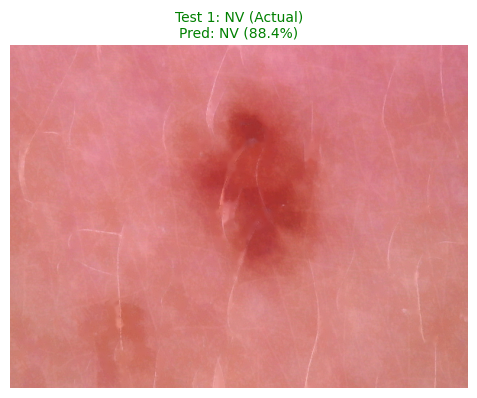

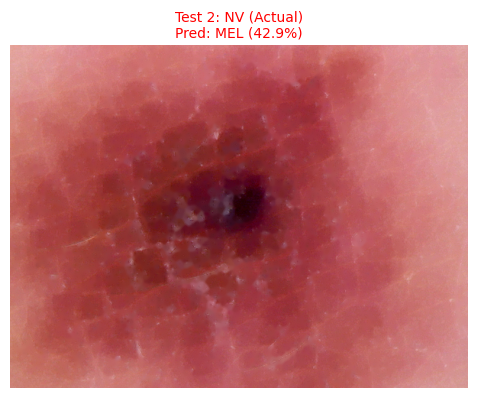

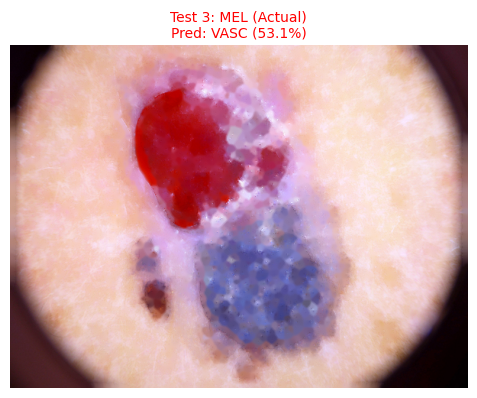

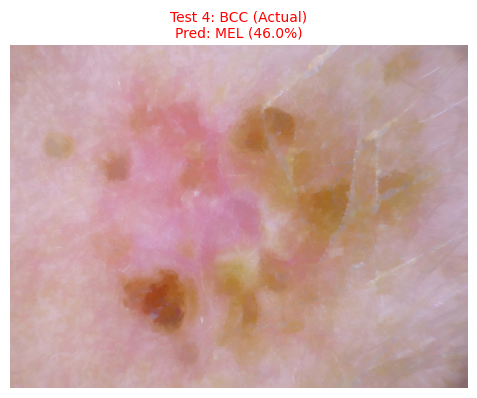

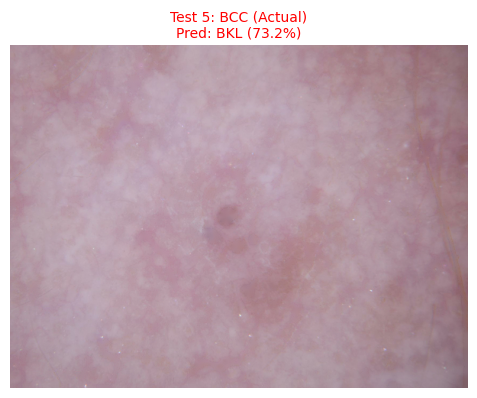

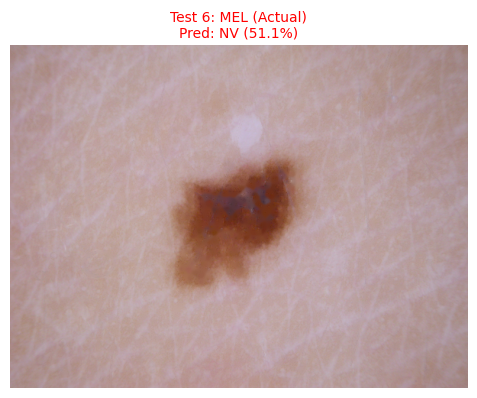

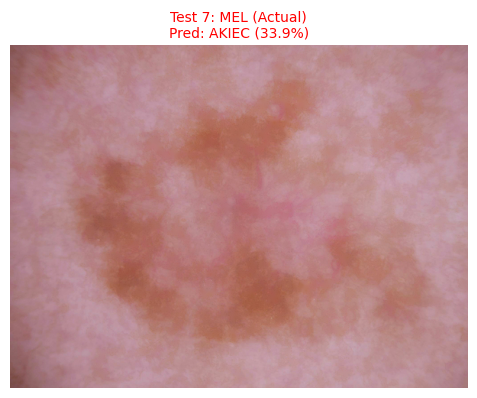

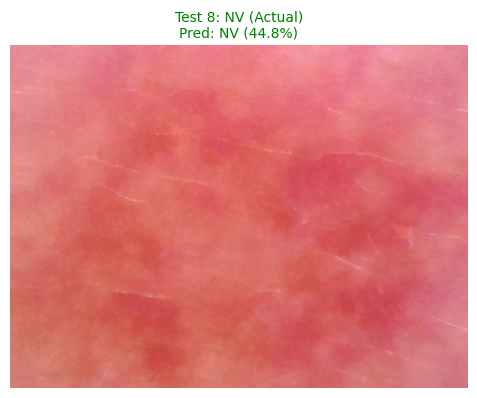

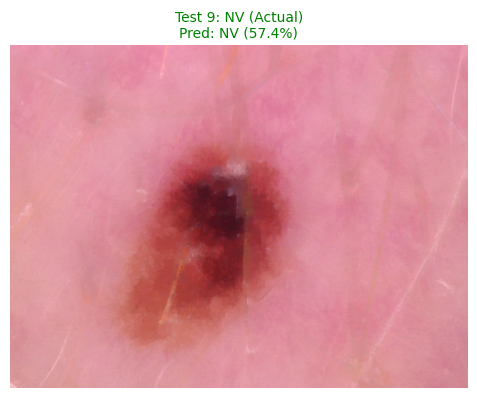

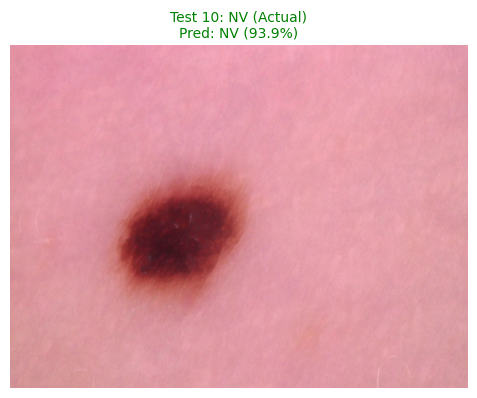

--- Syncing model data for high-quality plotting ---


Generating Plot Data: 100%|██████████| 126/126 [01:19<00:00,  1.59it/s]


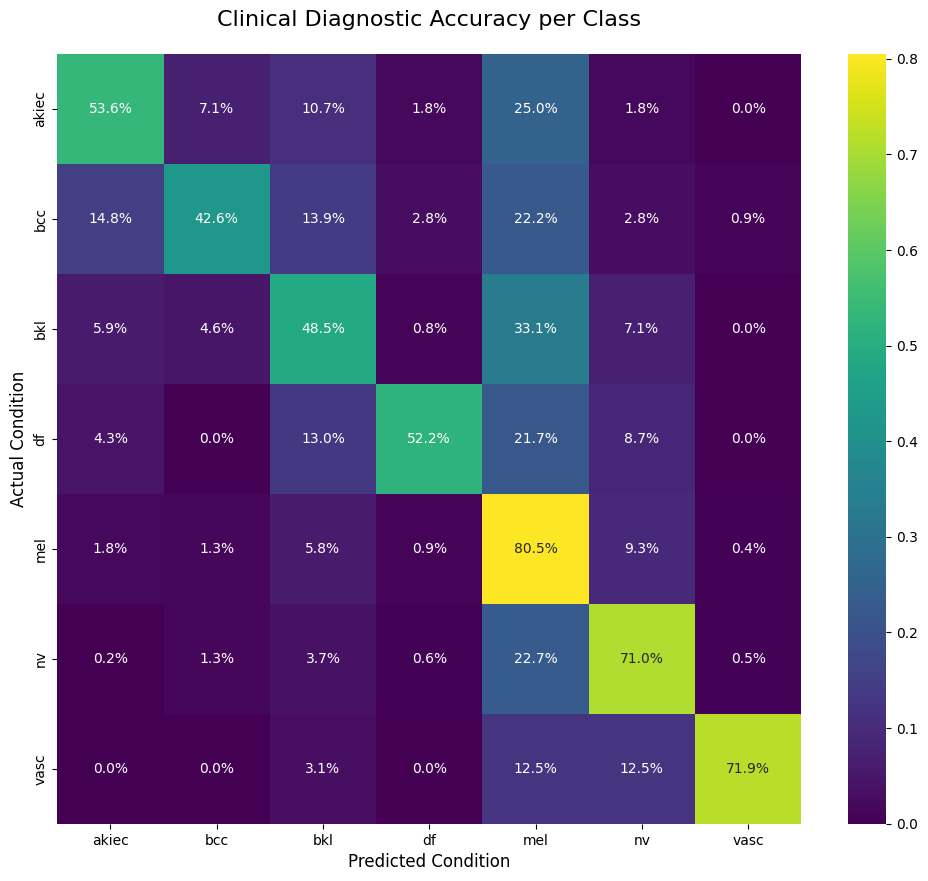

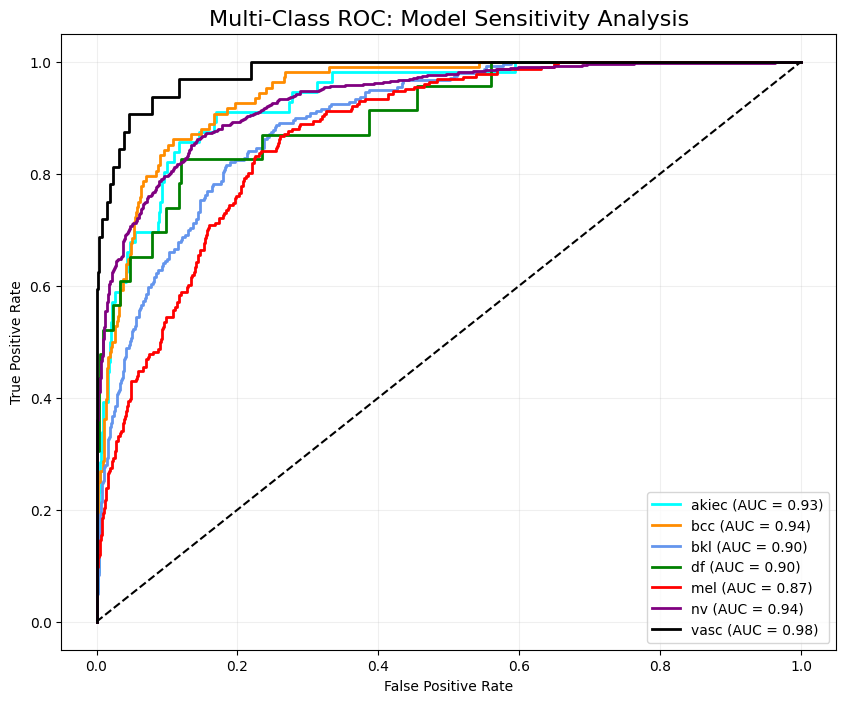

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from itertools import cycle
from tqdm import tqdm
from PIL import Image

# --- Helper function for missing logic ---
def test_my_model():
    print("Model 'EfficientNet_B4' loaded and ready for inference.")

# 1. Run a test search
print("\n--- Running Model Search Test ---")
test_my_model()

# 2. Adjusted Batch Prediction Function
def test_batch_predictions(num_tests=10):
    # Ensure model is in eval mode and loaded
    model.load_state_dict(torch.load('best_b4.pth'))
    model.eval()
    
    # Pick random indices from the test_df (better for "unseen" testing)
    random_indices = np.random.choice(len(test_df), num_tests, replace=False)
    
    # Use the existing inv_label_map from your previous cells
    print(f"--- Starting {num_tests} Random Predictions ---")
    
    for i, idx in enumerate(random_indices):
        img_path = test_df.iloc[idx]['image_path']
        actual_label = test_df.iloc[idx]['dx']
        
        # Preprocess
        raw_img = np.array(Image.open(img_path).convert('RGB'))
        clean_img = dullrazor(raw_img) 
        
        # Transform for model
        input_tensor = val_transform(image=clean_img)['image'].unsqueeze(0).to(DEVICE)
        
        # Predict
        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.softmax(output, dim=1)
            conf, pred_idx = torch.max(prob, dim=1)
        
        prediction = inv_label_map[pred_idx.item()]
        
        # Plotting
        color = 'green' if actual_label.lower() == prediction.lower() else 'red'
        plt.figure(figsize=(5, 4))
        plt.imshow(clean_img)
        plt.title(f"Test {i+1}: {actual_label.upper()} (Actual)\nPred: {prediction.upper()} ({conf.item()*100:.1f}%)", 
                  color=color, fontsize=10)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# Run the 10 tests
test_batch_predictions(num_tests=10)

# 3. RE-COLLECT DATA FOR PRO PLOTS
print("--- Syncing model data for high-quality plotting ---")
model.load_state_dict(torch.load('best_b4.pth'))
model.eval()

all_probs_list, all_labels_list, all_preds_list = [], [], []

with torch.no_grad():
    # Using val_loader or test_loader
    for images, labels in tqdm(val_loader, desc="Generating Plot Data"):
        outputs = model(images.to(DEVICE))
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)
        
        all_probs_list.extend(probs.cpu().numpy())
        all_labels_list.extend(labels.numpy())
        all_preds_list.extend(preds.cpu().numpy())

all_probs_array = np.array(all_probs_list)
all_labels_array = np.array(all_labels_list)
all_preds_array = np.array(all_preds_list)

# 4. GRAPH #1: Normalized Confusion Matrix Heatmap
def plot_pro_confusion_matrix():
    cm = confusion_matrix(all_labels_array, all_preds_array)
    # Normalize to show percentages
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_perc, annot=True, fmt='.1%', cmap='viridis', 
                xticklabels=label_map.keys(), yticklabels=label_map.keys())
    plt.title('Clinical Diagnostic Accuracy per Class', fontsize=16, pad=20)
    plt.xlabel('Predicted Condition', fontsize=12)
    plt.ylabel('Actual Condition', fontsize=12)
    plt.savefig('clinical_confusion_matrix.png', dpi=300)
    plt.show()

# 5. GRAPH #2: Multi-Class ROC Curve
def plot_pro_roc_curve():
    n_classes = NUM_CLASSES
    # One-hot encoding labels for ROC
    y_test_bin = np.eye(n_classes)[all_labels_array] 

    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs_array[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'black'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{list(label_map.keys())[i]} (AUC = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
    plt.title('Multi-Class ROC: Model Sensitivity Analysis', fontsize=16)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.2)
    plt.savefig('sensitivity_roc_curve.png', dpi=300)
    plt.show()

# Execute both
plot_pro_confusion_matrix()
plot_pro_roc_curve()

--- Starting 5 Random Predictions ---


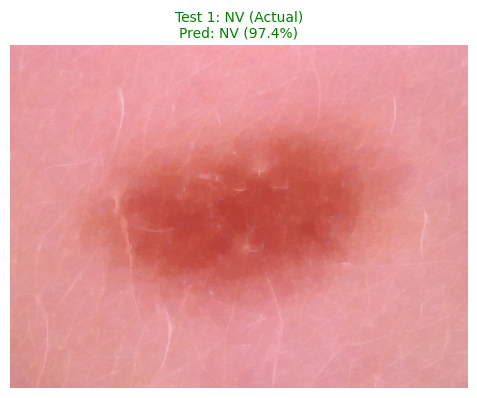

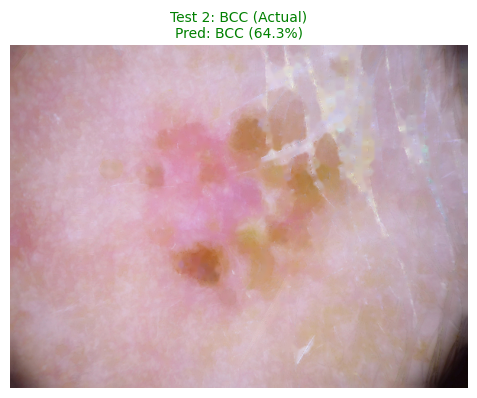

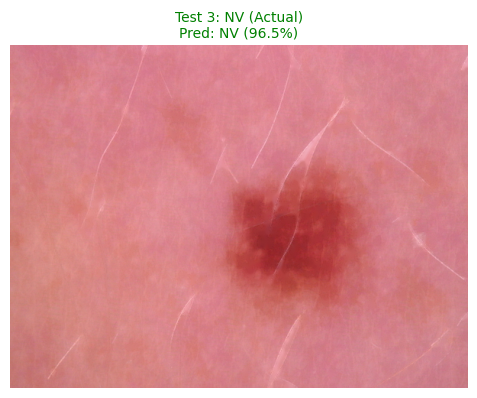

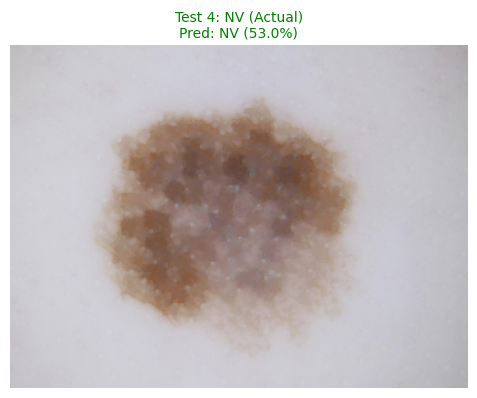

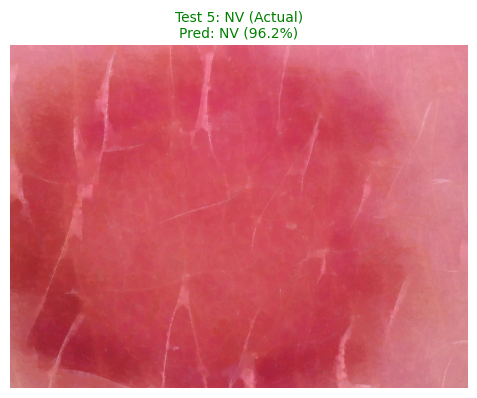

In [22]:
# 2. Adjusted Batch Prediction Function
def test_batch_predictions(num_tests= 5):
    # Ensure model is in eval mode and loaded
    model.load_state_dict(torch.load('best_b4.pth'))
    model.eval()
    
    # Pick random indices from the test_df (better for "unseen" testing)
    random_indices = np.random.choice(len(test_df), num_tests, replace=False)
    
    # Use the existing inv_label_map from your previous cells
    print(f"--- Starting {num_tests} Random Predictions ---")
    
    for i, idx in enumerate(random_indices):
        img_path = test_df.iloc[idx]['image_path']
        actual_label = test_df.iloc[idx]['dx']
        
        # Preprocess
        raw_img = np.array(Image.open(img_path).convert('RGB'))
        clean_img = dullrazor(raw_img) 
        
        # Transform for model
        input_tensor = val_transform(image=clean_img)['image'].unsqueeze(0).to(DEVICE)
        
        # Predict
        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.softmax(output, dim=1)
            conf, pred_idx = torch.max(prob, dim=1)
        
        prediction = inv_label_map[pred_idx.item()]
        
        # Plotting
        color = 'green' if actual_label.lower() == prediction.lower() else 'red'
        plt.figure(figsize=(5, 4))
        plt.imshow(clean_img)
        plt.title(f"Test {i+1}: {actual_label.upper()} (Actual)\nPred: {prediction.upper()} ({conf.item()*100:.1f}%)", 
                  color=color, fontsize=10)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# Run the 5tests
test_batch_predictions(num_tests=5)

--- Testing Single Prediction ---
  Predicted : MEL
  Confidence: 96.7%
  All class probabilities:
    mel     96.7%  █████████████████████████████
    bkl      1.2%  
    nv       1.2%  
    akiec    0.5%  
    bcc      0.3%  
    df       0.1%  
    vasc     0.0%  


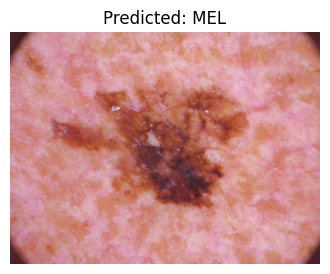

In [23]:
# Replace this with the path to the image you want to test
test_image_path = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0024310.jpg"

print(f"--- Testing Single Prediction ---")
# This calls your existing function from cell 21
prediction, probabilities = predict_single(test_image_path)

# Optional: Display the image you just predicted
plt.figure(figsize=(4, 4))
img = Image.open(test_image_path)
plt.imshow(img)
plt.title(f"Predicted: {prediction.upper()}")
plt.axis('off')
plt.show()

--- Testing Single Prediction ---
  Predicted : MEL
  Confidence: 34.6%
  All class probabilities:
    mel     34.6%  ██████████
    vasc    23.3%  ███████
    nv      20.2%  ██████
    bkl     16.2%  ████
    bcc      4.2%  █
    akiec    1.1%  
    df       0.3%  


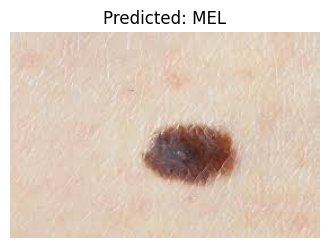

In [24]:
# Replace this with the path to the image you want to test
test_image_path = "/kaggle/input/datasets/suru12/sk-test-image/sk test image.jpg"

print(f"--- Testing Single Prediction ---")
# This calls your existing function from cell 21
prediction, probabilities = predict_single(test_image_path)

# Optional: Display the image you just predicted
plt.figure(figsize=(4, 4))
img = Image.open(test_image_path)
plt.imshow(img)
plt.title(f"Predicted: {prediction.upper()}")
plt.axis('off')
plt.show()